In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

# Settings after
warnings.filterwarnings('ignore')
plt.style.use('dark_background')

In [2]:
df = pd.read_csv('../data/processed/british_gp_2023_clean.csv')
model = joblib.load('../models/lap_time_predictor.pkl')

print(df.shape)
print('✅ Data and model loaded!')
print('Model type:', type(model))

(802, 15)
✅ Data and model loaded!
Model type: <class 'xgboost.sklearn.XGBRegressor'>


In [3]:
# Pick Verstappen's laps for simulation
Driver = 'VER'
Driver_laps = df[df['Driver'] == Driver].copy()

print(f'Driver: {Driver}')
print(f'total laps:{len(Driver_laps)}')
print(f'Lap range: {Driver_laps["LapNumber"].min()} to {Driver_laps["LapNumber"].max()}')

Driver: VER
total laps:45
Lap range: 2.0 to 52.0


In [6]:
def simulate_strategy(driver_laps, pit_lap):
    #stint 1: laps before pit stop
    stint1 = driver_laps[driver_laps['LapNumber'] < pit_lap]

    #stint2: laps before pit stop
    stint2 = driver_laps[driver_laps['LapNumber'] > pit_lap]

    #Total race time  = sum of all lap times
    total_time = stint1['LapTimeSeconds'].sum() + stint2['LapTimeSeconds'].sum()

    return total_time

In [9]:
# Test every pit lap from lap 10 to lap 40
pit_laps = range(10, 40)
results = []

for pit_lap in pit_laps:
    total_time = simulate_strategy(Driver_laps, pit_lap)
    results.append({
        'PitLap': pit_lap,
        'TotalTime': total_time
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Find the optimal pit lap
best_pit = results_df.loc[results_df['TotalTime'].idxmin()]
print(f'Optimal pit lap: {int(best_pit["PitLap"])}')
print(f'Total race time: {best_pit["TotalTime"]:.1f} seconds')

Optimal pit lap: 14
Total race time: 4049.8 seconds


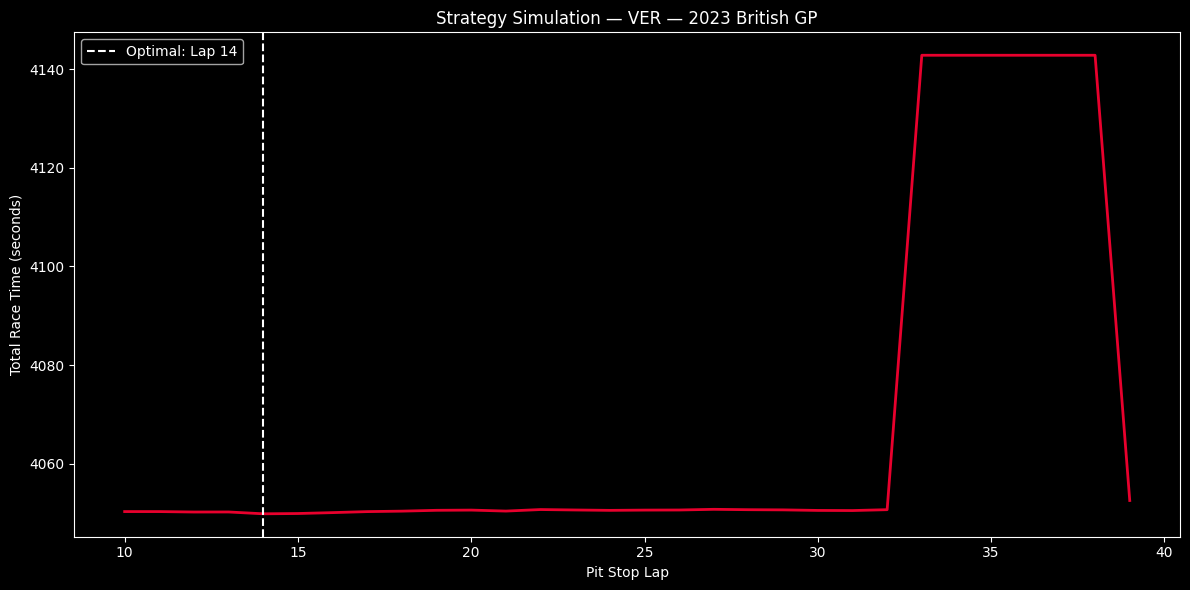

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(results_df['PitLap'], results_df['TotalTime'], 
        color='#E8002D', linewidth=2)

# Mark the optimal pit lap
ax.axvline(best_pit['PitLap'], color='white', 
           linestyle='--', label=f'Optimal: Lap {int(best_pit["PitLap"])}')

ax.set_xlabel('Pit Stop Lap')
ax.set_ylabel('Total Race Time (seconds)')
ax.set_title('Strategy Simulation — VER — 2023 British GP')
ax.legend()
plt.tight_layout()
plt.show()